In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn pyspellchecker

  Using cached pyspellchecker-0.8.2-py3-none-any.whl (7.1 MB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Joshua\amdira-projects\fraud-detection\fraud-venv\Scripts\python.exe -m pip install --upgrade pip' command.


Nova Credit fraudulent Transaction Detection for Digital Money Transfer:

This Project aims to strengthen Novas transaction security process by detecting fraudulent transactions at the point of transaction processing. 

This project will develop a machine-learning model that provides fast, data-driven fraud predictions to support accurate detection, regulatory compliance, and improved customer experience.



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mp
import seaborn as sn

# Load the dataset
data_path = r'C:\Users\Joshua\amdira-projects\fraud-detection\data\nova_pay_combined.csv'
data = pd.read_csv(data_path)


print(f"Dataset loaded successfully: {len(data)} rows and {len(data.columns)} columns." )



Dataset loaded successfully: 11400 rows and 26 columns.


In [17]:
# Explore the dataset
print("Dataset Information - First five rows:")
print(data.head().to_string())
print("-----  -----")
print("Last five rows:")
print(data.tail().to_string())
print("-----  -----")
print("\n\n\n\nDataset Information (types and structures):")
print(data.info())

Dataset Information - First five rows:
                         transaction_id                           customer_id                         timestamp home_country source_currency dest_currency channel amount_src  amount_usd   fee  exchange_rate_src_to_dest                             device_id  new_device      ip_address ip_country  location_mismatch  ip_risk_score  kyc_tier  account_age_days  device_trust_score  chargeback_history_count  risk_score_internal  txn_velocity_1h  txn_velocity_24h  corridor_risk  is_fraud
0  fee8542d-8ee6-4b0d-9671-c294dd08ed26  402cccc9-28de-45b3-9af7-cc5302aa1f93  2022-10-03 18:40:59.468549+00:00           US             USD           CAD     ATM     278.19      278.19  4.25                   1.351351  9f292dcc-3297-4947-a260-6a1ef69041ff       False  221.78.171.180         US              False          0.123  standard               263               0.522                         0                0.223                0                 0            0.0  

In [20]:
# Lets count missing values in the dataset
missing_values = (data.isnull().sum()/len(data)) * 100
print("Missing values in each column (%):\n", missing_values)

Missing values in each column (%):
 transaction_id               0.000000
customer_id                  0.000000
timestamp                    0.254386
home_country                 0.000000
source_currency              0.000000
dest_currency                0.000000
channel                      0.000000
amount_src                   0.000000
amount_usd                   2.675439
fee                          2.587719
exchange_rate_src_to_dest    0.000000
device_id                    0.000000
new_device                   0.000000
ip_address                   2.675439
ip_country                   2.640351
location_mismatch            0.000000
ip_risk_score                0.000000
kyc_tier                     2.631579
account_age_days             0.000000
device_trust_score           2.587719
chargeback_history_count     0.000000
risk_score_internal          0.000000
txn_velocity_1h              0.000000
txn_velocity_24h             0.000000
corridor_risk                0.000000
is_fraud      

In [22]:
# lets summary statistics of the dataset    
print("Summary statistics of the dataset:\n\n")
print(data.describe().to_string())

Summary statistics of the dataset:


         amount_usd           fee  exchange_rate_src_to_dest  ip_risk_score  account_age_days  device_trust_score  chargeback_history_count  risk_score_internal  txn_velocity_1h  txn_velocity_24h  corridor_risk      is_fraud
count  11095.000000  11105.000000               11400.000000   11400.000000      11400.000000        11105.000000              11400.000000         11400.000000     11400.000000      11400.000000   11400.000000  11400.000000
mean     452.022083    100.309441                 167.540397       0.396726        393.793158            0.653681                  0.048509             0.267134         0.458333          0.723509       0.045501      0.087456
std     1403.973062    958.128504                 382.023827       0.270507        342.348393            0.273012                  0.256194             0.142983         1.524494          1.958390       0.084942      0.282515
min        7.230000     -1.000000                   0.592000   

In [23]:
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)
print("Duplicate rows:")
print(data[data.duplicated(keep=False)].to_string()) # Display duplicate rows

Number of duplicate rows: 200
Duplicate rows:
                             transaction_id                           customer_id                         timestamp home_country source_currency dest_currency  channel amount_src  amount_usd      fee  exchange_rate_src_to_dest                             device_id  new_device       ip_address ip_country  location_mismatch  ip_risk_score     kyc_tier  account_age_days  device_trust_score  chargeback_history_count  risk_score_internal  txn_velocity_1h  txn_velocity_24h  corridor_risk  is_fraud
57     4662cb2d-21b2-4390-ba38-5a1eddebdc7c  402cccc9-28de-45b3-9af7-cc5302aa1f93  2022-10-09 20:21:25.468549+00:00           US             USD           GBP   mobile     152.75      152.75     3.35                   0.800000  9f5cc9be-f9f0-4911-bdc4-d9e4c8a871fa       False   194.179.17.152         US              False          0.328     standard               263               0.522                         0                0.223                5    

Outlier Detection Boxplot:


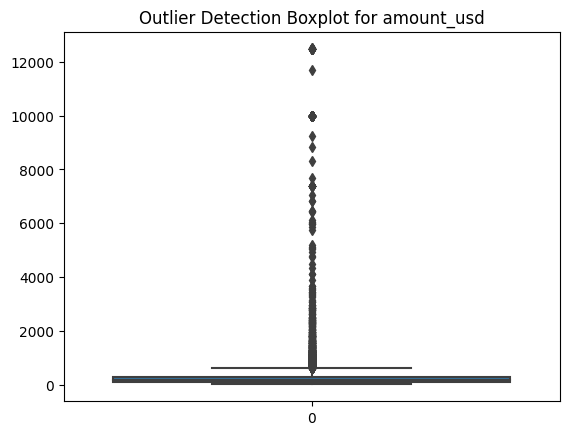

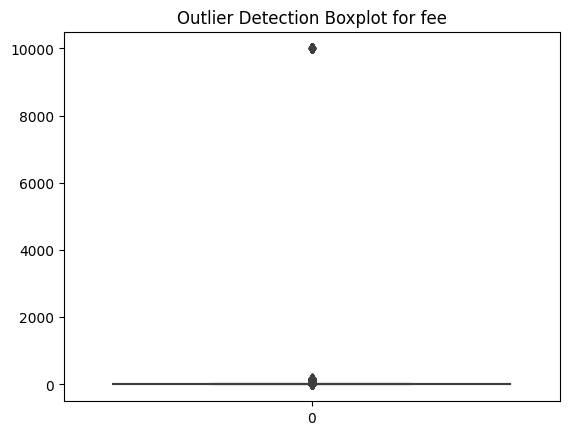

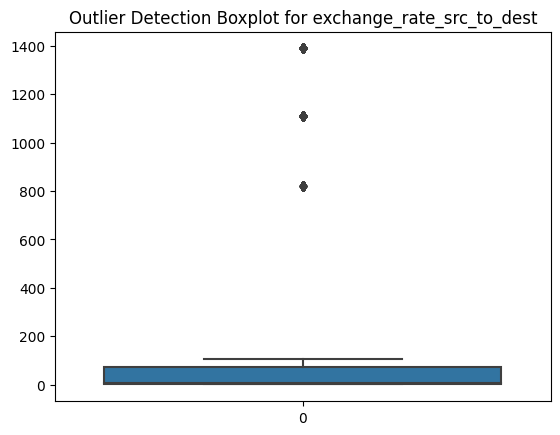

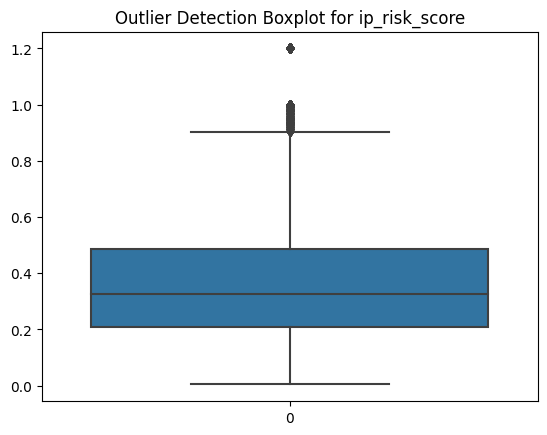

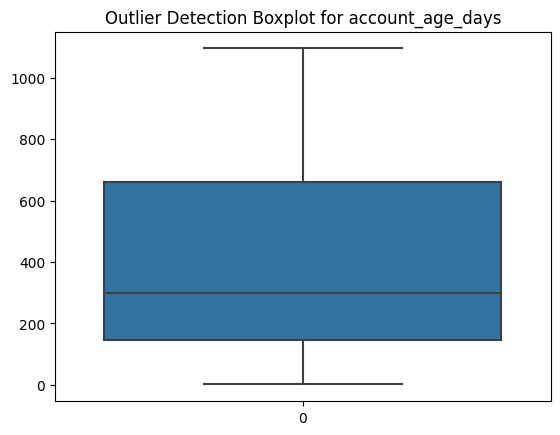

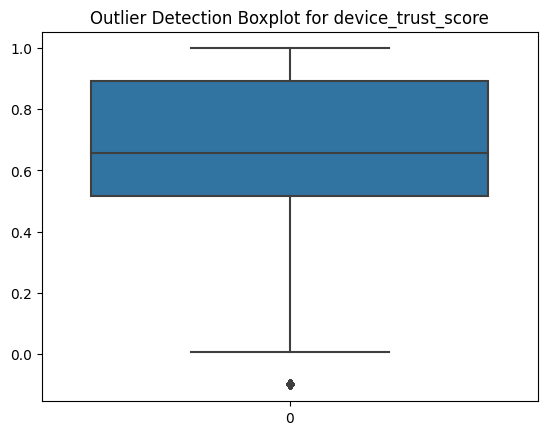

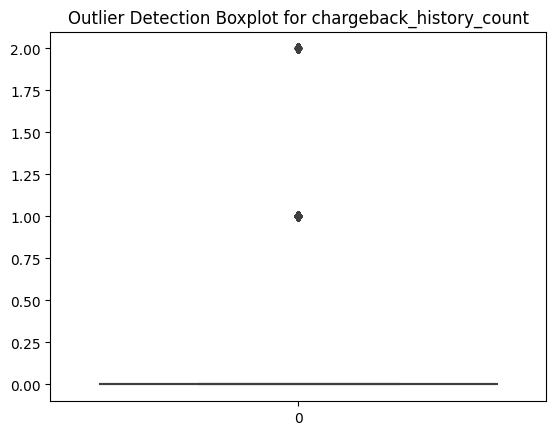

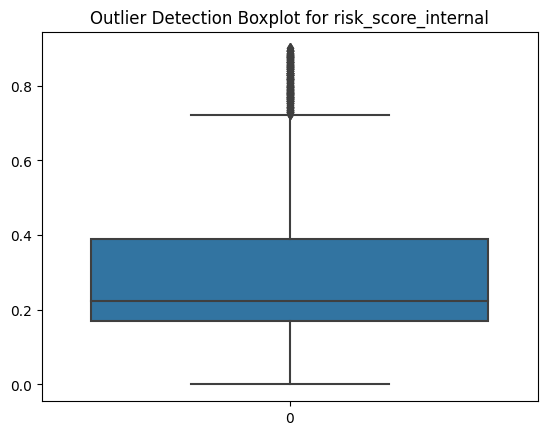

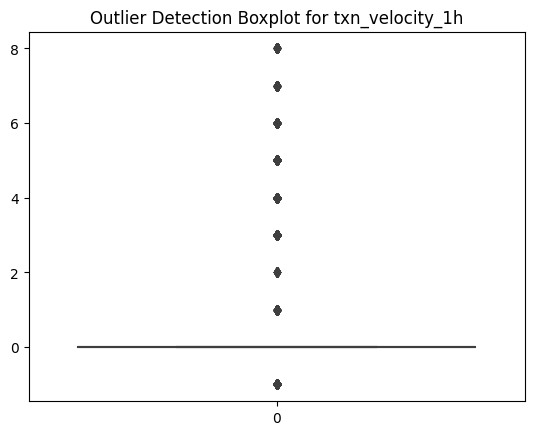

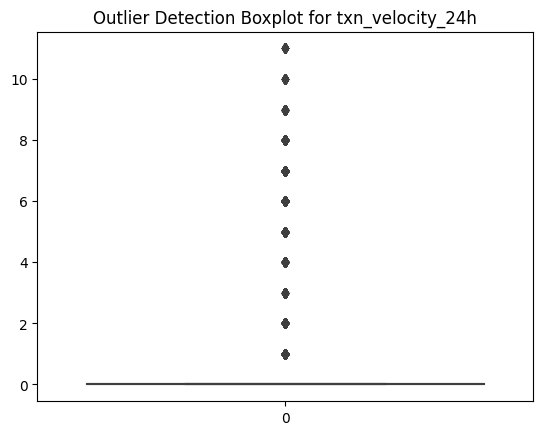

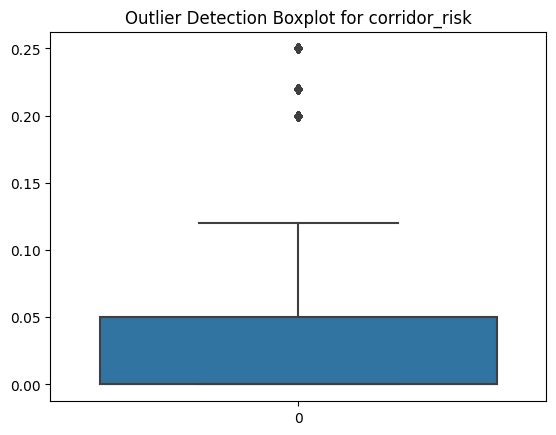

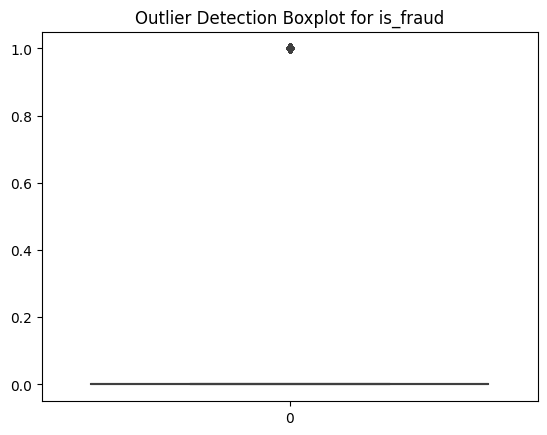

In [24]:
# check for outliers in the dataset using boxplots

print("Outlier Detection Boxplot:")
for column in data.select_dtypes(include=[np.number]).columns:
    sn.boxplot(data=data[column])
    mp.title(f'Outlier Detection Boxplot for {column}')
    mp.show()
# sn.boxplot(data=data['ip_risk_score'])
# mp.title('Outlier Detection Boxplot')
# mp.show()

In [46]:
print("Full category Audit")
for col in data.select_dtypes(include=['object', 'string']).columns.tolist():
    print(f"\nColumn: {col}")
    print(data[col].value_counts())
    print("-----  -----")

Full category Audit

Column: transaction_id
9cfbbce9-979c-4d34-bf5a-98531362bd9a    2
1c925529-c86f-4910-86e8-e4d83cebfd37    2
a9198fb0-d831-48df-b434-c30a39078aa3    2
70ae28a6-f5d4-4cda-8317-994c115abf8d    2
c2c365cb-83d0-4433-aa4a-d7ffceeab4f6    2
                                       ..
c195dd6e-58b4-442c-9cc4-98adb52c68f0    1
13933d53-bac4-4e17-9db1-b1b779360ecb    1
cc899474-3aed-4cd5-9172-21ab44117d31    1
72a1d0c8-3f08-406d-b568-5364d01b92a8    1
fdffeb16-192a-4483-9b1e-9928e23269c2    1
Name: transaction_id, Length: 11200, dtype: int64
-----  -----

Column: customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1510
d71c91b4-fee8-4104-9856-a5c6109a62e3    1355
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1345
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1066
af8ca4c4-8703-4c55-b66c-2b76cd70040d     915
                                        ... 
aabb3f37-897d-494d-8692-61cafe6d4bfe       1
674b253e-6d4a-43a1-9972-dab8ea3ce646       1
3744e498-db4c-49b0-b158-0adad1bd06bf       1
a4393

In [47]:
# Find misspelled values in categorical text columns

import re
from spellchecker import SpellChecker

spell = SpellChecker()
known_terms = [
    "US", "UK", "CA", "USD", "GBP", "CAD", "EUR", "MXN", "NGN",
    "INR", "CNY", "PHP", "ATM", "KYC", "unknown", "nan",
    "mobile", "web", "standard", "enhanced", "low"
]
spell.word_frequency.load_words(known_terms)

categorical_columns = [
    column for column in data.select_dtypes(include=["object", "string"]).columns
    if data[column].nunique(dropna=True) <= 100
]
incorrect_values_by_column = {}

for column in categorical_columns:
    incorrect_values = []
    for value in data[column].dropna().unique():
        words = re.findall(r"[A-Za-z]+", str(value))
        if spell.unknown(words):
            incorrect_values.append(value)
    if incorrect_values:
        incorrect_values_by_column[column] = incorrect_values

if incorrect_values_by_column:
    display(pd.DataFrame({
        column: pd.Series(values)
        for column, values in incorrect_values_by_column.items()
    }))
else:
    print("No misspelled values found.")

,channel,kyc_tier
0,mobille,standrd
1,weeb,enhancd


In [49]:
# Find values that cannot be parsed as numbers
print("Checking for values that cannot be parsed as numbers in numeric columns...")
numeric_columns = set(data.select_dtypes(include=["number"]).columns)

for column in data.select_dtypes(include=["object", "string"]).columns:
    non_missing_values = data[column].dropna()
    if not non_missing_values.empty:
        parsed_values = pd.to_numeric(non_missing_values, errors="coerce")
        if parsed_values.notna().mean() >= 0.9:
            numeric_columns.add(column)

invalid_number_values = []
for column in sorted(numeric_columns):
    invalid_values = data.loc[
        data[column].notna()
        & pd.to_numeric(data[column], errors="coerce").isna(),
        column
    ].value_counts()
    for value, count in invalid_values.items():
        invalid_number_values.append({
            "column": column,
            "value that will not parse": value,
            "count": count
        })

if invalid_number_values:
    display(pd.DataFrame(invalid_number_values))
else:
    print("All values in numeric columns parse as numbers.")

Checking for values that cannot be parsed as numbers in numeric columns...


,column,value that will not parse,count
0,amount_src,"9,998.85",1
1,amount_src,"9,995.95",1
2,amount_src,"1,541.55",1
3,amount_src,"9,991.24",1


In [70]:
print("Pattern analysis of missing values in IP-related columns...")    
missing_indices_1 = data[data['ip_address'].isnull()].index.tolist()
gaps = pd.Series(missing_indices_1).diff()
print("Gaps between missing values:\n", gaps.value_counts())

is_na = data['ip_address'].isna()
# Look at the raw data surrounding the missing blocks
missing_indices = data[is_na].index

# Print the 2 rows before and after the first few missing zones
for idx in missing_indices[:5]:
    print(data.iloc[max(0, idx-2) : min(len(data), idx+3)])
    print("="*40)

# Check which columns are failing at the exact same time as IP/Risk data
print(data[data['amount_usd'].isna()][['fee', 'kyc_tier', 'device_trust_score']].isna().sum())

Pattern analysis of missing values in IP-related columns...
Gaps between missing values:
 16.0     11
8.0      11
7.0      10
2.0       9
31.0      9
         ..
154.0     1
149.0     1
75.0      1
59.0      1
132.0     1
Length: 90, dtype: int64
                          transaction_id  \
11  43a11314-6420-4e23-b0a8-69d5f010da86   
12  2743f55c-3693-4219-a62c-5b3d22caf2c6   
13  1a34a095-3be4-4a69-a22e-803be566526c   
14  293c5ffb-ea4a-4ddb-855d-b159d7faee37   
15  d48dbfbf-2b25-47e0-8470-66e8996faa0f   

                             customer_id                         timestamp  \
11  af8ca4c4-8703-4c55-b66c-2b76cd70040d  2022-10-04 22:54:28.468549+00:00   
12  d71c91b4-fee8-4104-9856-a5c6109a62e3  2022-10-05 00:57:43.468549+00:00   
13  7041b9c1-3719-4ca8-9a6b-811b47cea6c0  2022-10-05 07:04:39.468549+00:00   
14  7bd5200c-5d19-44f0-9afe-8b339a05366b  2022-10-05 13:34:02.468549+00:00   
15  70a93d26-8e3a-4179-900c-a4a7a74d08e5  2022-10-05 15:32:41.468549+00:00   

   home_country sou

In [74]:
print("Filling missing values in 'amount_usd', fee and device_trust_score column with their median and rechecking for missing values...")
data['amount_usd'] = data['amount_usd'].fillna(data['amount_usd'].median())
data['fee'] = data['fee'].fillna(data['fee'].median())
data['device_trust_score'] = data['device_trust_score'].fillna(data['device_trust_score'].median())


# recheck for missing values after filling
print("Missing values in 'amount_usd':", data['amount_usd'].isnull().sum())
print("Missing values in 'fee':", data['fee'].isnull().sum())
print("Missing values in 'device_trust_score':", data['device_trust_score'].isnull().sum())

Filling missing values in 'amount_usd', fee and device_trust_score column with their median and rechecking for missing values...
Missing values in 'amount_usd': 0
Missing values in 'fee': 0
Missing values in 'device_trust_score': 0


In [78]:
# filling Ip_address, ip_risk_score, and ip_risk_score_2 with 'Unknown' or a placeholder value
print("Filling missing values in 'ip_address', 'ip_risk_score', 'ip_country', and 'kyc_tier' columns with 'Unknown' and rechecking for missing values...")
data['ip_address'] = data['ip_address'].fillna('Unknown')
data['ip_risk_score'] = data['ip_risk_score'].fillna('Unknown')
data['ip_country'] = data['ip_country'].fillna('Unknown')
data['kyc_tier'] = data['kyc_tier'].fillna('Unknown')

# rechecking for missing values
print("missing values in 'ip_address':", data['ip_address'].isnull().sum())
print("missing values in 'ip_country':", data['ip_country'].isnull().sum())
print("missing values in 'kyc_tier':", data['kyc_tier'].isnull().sum())


Filling missing values in 'ip_address', 'ip_risk_score', 'ip_country', and 'kyc_tier' columns with 'Unknown' and rechecking for missing values...
missing values in 'ip_address': 0
missing values in 'ip_country': 0
missing values in 'kyc_tier': 0
